# OpenCV + MobileNetV2 batch video emotion timeline

Este notebook processa uma lista de vídeos, gera uma cópia anotada com caixa delimitadora e emoção aparente na face principal, e salva um JSON simples com segmentos temporais por emoção. O foco é validação visual exploratória, não uso clínico.


Nesta celula vamos importar as bibliotecas usadas para ler videos, rodar o modelo, desenhar overlays e mostrar os resultados.


In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
from typing import Any, Sequence
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display


Aqui definimos os caminhos, limiares, rotulos e parametros visuais que controlam todo o lote de processamento.


In [2]:
IMAGE_SIZE: tuple[int, int] = (224, 224)
EMOTION_LABELS: list[str] = [
    'angry',
    'disgust',
    'fear',
    'happy',
    'neutral',
    'sad',
    'surprise',
]

APPARENT_LABEL_MAP: dict[str, str] = {
    'angry': 'apparent_anger_expression',
    'disgust': 'apparent_disgust_expression',
    'fear': 'apparent_fear_expression',
    'happy': 'apparent_joy_expression',
    'neutral': 'apparent_neutral_expression',
    'sad': 'apparent_sad_expression',
    'surprise': 'apparent_surprise_expression',
}

MODEL_DIR: Path = Path('models')
MODEL_PATH: Path = MODEL_DIR / 'model.h5'

# Preencha esta lista com os caminhos dos vídeos que deseja processar.
VIDEO_PATHS: list[str] = [
    'data/video/domestic_abuse1.mp4',
    'data/video/domestic_abuse2.mp4',
    # 'data/videos/sample_02.mp4',
]

OUTPUT_JSON_DIR: Path = Path('outputs/emotion_timelines')
OUTPUT_VIDEO_DIR: Path = Path('outputs/annotated_videos')

MIN_CONFIDENCE: float = 0.50
MIN_SEGMENT_DURATION_SECONDS: float = 1.0
SAMPLE_FPS_FOR_TIMELINE: float = 2.0

FACE_SCALE_FACTOR: float = 1.1
FACE_MIN_NEIGHBORS: int = 5
FACE_MIN_SIZE: tuple[int, int] = (60, 60)

BOX_THICKNESS: int = 2
FONT_SCALE: float = 0.65
TEXT_THICKNESS: int = 2
TEXT_MARGIN_Y: int = 10
MAX_PREVIEW_FRAMES: int = 4

UNCERTAIN_LABEL: str = 'uncertain'
NO_FACE_LABEL: str = 'no_face'

EMOTION_COLORS: dict[str, tuple[int, int, int]] = {
    'apparent_anger_expression': (0, 0, 255),
    'apparent_disgust_expression': (0, 140, 255),
    'apparent_fear_expression': (255, 0, 255),
    'apparent_joy_expression': (0, 255, 0),
    'apparent_neutral_expression': (255, 255, 0),
    'apparent_sad_expression': (255, 0, 0),
    'apparent_surprise_expression': (255, 255, 255),
}
UNCERTAIN_COLOR: tuple[int, int, int] = (0, 255, 255)
TEXT_COLOR: tuple[int, int, int] = (255, 255, 255)

display(Markdown(
    '\n'.join([
        '### Configuração atual',
        f'- Model path: `{MODEL_PATH}`',
        f'- Vídeos configurados: `{len(VIDEO_PATHS)}`',
        f'- JSON output dir: `{OUTPUT_JSON_DIR}`',
        f'- Annotated video output dir: `{OUTPUT_VIDEO_DIR}`',
        f'- Min confidence: `{MIN_CONFIDENCE:.2f}`',
        f'- Timeline sample FPS: `{SAMPLE_FPS_FOR_TIMELINE:.2f}`',
    ])
))


### Configuração atual
- Model path: `models\model.h5`
- Vídeos configurados: `2`
- JSON output dir: `outputs\emotion_timelines`
- Annotated video output dir: `outputs\annotated_videos`
- Min confidence: `0.50`
- Timeline sample FPS: `2.00`

Nesta celula criamos os utilitarios de face detection, carregamento do modelo, pre-processamento e desenho da anotacao no frame.


In [3]:
def load_face_detector() -> cv2.CascadeClassifier:
    """Load and validate the OpenCV Haar cascade face detector."""
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    detector = cv2.CascadeClassifier(cascade_path)
    if detector.empty():
        raise RuntimeError(f'Could not load Haar cascade from: {cascade_path}')
    return detector


def load_emotion_model(model_path: Path) -> tf.keras.Model:
    """Load a full Keras model saved as .h5 or .keras for inference."""
    if not model_path.exists():
        raise FileNotFoundError(
            f'Model file not found at {model_path}. Place the exported Keras model there before running inference.'
        )
    return tf.keras.models.load_model(model_path)


def preprocess_face_roi(face_bgr: np.ndarray, image_size: tuple[int, int]) -> np.ndarray:
    """Convert one face ROI into a normalized batch for model inference."""
    resized = cv2.resize(face_bgr, image_size, interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    batch = np.expand_dims(rgb.astype(np.float32), axis=0)
    return batch


def predict_emotion(
    model: tf.keras.Model,
    face_bgr: np.ndarray,
    labels: Sequence[str],
) -> tuple[str, str, float]:
    """Predict the raw emotion label, mapped apparent label, and confidence for one face."""
    batch = preprocess_face_roi(face_bgr=face_bgr, image_size=IMAGE_SIZE)
    probs = model.predict(batch, verbose=0)[0]
    class_idx = int(np.argmax(probs))
    raw_label = labels[class_idx]
    apparent_label = APPARENT_LABEL_MAP[raw_label]
    confidence = float(probs[class_idx])
    return raw_label, apparent_label, confidence


def sanitize_video_id(video_path: Path) -> str:
    """Create a filesystem-safe video id derived from the filename stem."""
    safe_chars = [char if char.isalnum() or char in {'-', '_'} else '_' for char in video_path.stem]
    safe_stem = ''.join(safe_chars).strip('_')
    return safe_stem or 'video'


def choose_primary_face(faces: Sequence[tuple[int, int, int, int]]) -> tuple[int, int, int, int] | None:
    """Return the largest detected face, assuming it is the primary subject."""
    if not faces:
        return None
    return max((tuple(map(int, face)) for face in faces), key=lambda box: box[2] * box[3])


def build_video_writer(output_path: Path, fps: float, frame_size: tuple[int, int]) -> cv2.VideoWriter:
    """Create a VideoWriter for the annotated MP4 copy."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    safe_fps = fps if fps > 0 else 30.0
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, safe_fps, frame_size)
    if not writer.isOpened():
        raise RuntimeError(f'Could not open VideoWriter for: {output_path}')
    return writer


def draw_face_annotation(
    frame: np.ndarray,
    box: tuple[int, int, int, int],
    shown_label: str,
    confidence: float,
) -> np.ndarray:
    """Draw one bounding box and overlay text onto the frame."""
    x, y, w, h = box
    color = EMOTION_COLORS.get(shown_label, UNCERTAIN_COLOR if shown_label == UNCERTAIN_LABEL else (180, 180, 180))
    cv2.rectangle(frame, (x, y), (x + w, y + h), color, BOX_THICKNESS)
    text = f'{shown_label}: {confidence:.2f}'
    text_origin = (x, max(0, y - TEXT_MARGIN_Y))
    cv2.putText(
        frame,
        text,
        text_origin,
        cv2.FONT_HERSHEY_SIMPLEX,
        FONT_SCALE,
        TEXT_COLOR,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )
    return frame


Aqui montamos a consolidacao temporal, o payload JSON, a escrita do video anotado e o processamento de cada video em streaming.


In [4]:
def _sample_every_n_frames(source_fps: float, desired_sample_fps: float) -> tuple[int, float]:
    """Convert a desired timeline sampling FPS into an integer frame step and effective FPS."""
    safe_source_fps = source_fps if source_fps > 0 else 30.0
    safe_desired = desired_sample_fps if desired_sample_fps > 0 else safe_source_fps
    frame_step = max(1, int(round(safe_source_fps / safe_desired)))
    effective_fps = safe_source_fps / frame_step
    return frame_step, effective_fps


def _close_segment(segment_points: list[dict[str, Any]], step_seconds: float) -> dict[str, Any]:
    """Aggregate contiguous timeline points of the same emotion into one segment."""
    confidences = [float(point['confidence']) for point in segment_points if point['confidence'] is not None]
    start_s = float(segment_points[0]['timestamp_s'])
    end_s = float(segment_points[-1]['timestamp_s']) + step_seconds
    return {
        'start_s': round(start_s, 4),
        'end_s': round(end_s, 4),
        'mean_confidence': round(float(np.mean(confidences)), 4) if confidences else None,
        'peak_confidence': round(float(np.max(confidences)), 4) if confidences else None,
        'frame_count': len(segment_points),
    }


def build_emotion_timeline(
    sample_points: list[dict[str, Any]],
    *,
    step_seconds: float,
    min_segment_duration_seconds: float,
) -> list[dict[str, Any]]:
    """Build one compact per-emotion timeline from sampled points."""
    if not sample_points:
        return []

    sampled_points_with_face = sum(1 for point in sample_points if point['has_face'])
    segments_by_label: dict[str, list[dict[str, Any]]] = defaultdict(list)
    points_by_label: dict[str, list[dict[str, Any]]] = defaultdict(list)

    current_label: str | None = None
    current_segment_points: list[dict[str, Any]] = []

    def flush_current_segment() -> None:
        nonlocal current_label, current_segment_points
        if not current_label or not current_segment_points:
            current_label = None
            current_segment_points = []
            return
        segment = _close_segment(current_segment_points, step_seconds=step_seconds)
        duration_seconds = float(segment['end_s']) - float(segment['start_s'])
        if duration_seconds >= min_segment_duration_seconds:
            segments_by_label[current_label].append(segment)
            points_by_label[current_label].extend(current_segment_points)
        current_label = None
        current_segment_points = []

    for point in sample_points:
        label = point['label']
        if not label:
            flush_current_segment()
            continue

        if current_label is None:
            current_label = label
            current_segment_points = [point]
            continue

        previous_point = current_segment_points[-1]
        contiguous = float(point['timestamp_s']) <= float(previous_point['timestamp_s']) + (step_seconds * 1.5)
        if label == current_label and contiguous:
            current_segment_points.append(point)
            continue

        flush_current_segment()
        current_label = label
        current_segment_points = [point]

    flush_current_segment()

    emotion_rows: list[dict[str, Any]] = []
    for label in sorted(segments_by_label):
        label_segments = segments_by_label[label]
        if not label_segments:
            continue
        label_points = points_by_label[label]
        confidences = [float(point['confidence']) for point in label_points if point['confidence'] is not None]
        duration_seconds = sum(float(segment['end_s']) - float(segment['start_s']) for segment in label_segments)
        presence_ratio = (len(label_points) / sampled_points_with_face) if sampled_points_with_face else 0.0
        emotion_rows.append(
            {
                'label': label,
                'presence_ratio': round(float(presence_ratio), 4),
                'duration_seconds': round(float(duration_seconds), 4),
                'mean_confidence': round(float(np.mean(confidences)), 4) if confidences else None,
                'peak_confidence': round(float(np.max(confidences)), 4) if confidences else None,
                'segments': label_segments,
            }
        )
    return emotion_rows


def build_failure_payload(
    *,
    video_path: Path,
    annotated_video_path: Path,
    limitation: str,
) -> dict[str, Any]:
    """Create a fail-safe JSON payload when a video cannot be processed."""
    video_id = sanitize_video_id(video_path)
    return {
        'schema_version': 'emotion_timeline_v1',
        'video': {
            'video_id': video_id,
            'source_path': str(video_path),
            'source_name': video_path.name,
            'annotated_video_path': None,
            'duration_seconds': 0.0,
            'source_fps': 0.0,
            'timeline_sample_fps': 0.0,
            'frames_total': 0,
            'frames_scored': 0,
            'frames_with_face': 0,
            'frames_without_face': 0,
            'multiple_faces_observed': False,
        },
        'model': {
            'name': 'emotion_mobilenetv2',
            'model_path': str(MODEL_PATH),
            'image_size': list(IMAGE_SIZE),
            'min_confidence': MIN_CONFIDENCE,
        },
        'emotions': [],
        'speech': {
            'transcript': None,
            'segments': [],
        },
        'limitations': [
            'Emoção aparente não equivale a estado mental real.',
            'Somente a maior face por frame foi analisada.',
            limitation,
        ],
    }


def write_json_payload(payload: dict[str, Any], output_path: Path) -> None:
    """Persist one JSON payload with UTF-8 and indentation for easy inspection."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')


def process_video_asset(
    video_path: str | Path,
    *,
    model: tf.keras.Model,
    detector: cv2.CascadeClassifier,
) -> dict[str, Any]:
    """Process one video end-to-end, producing an annotated copy and a compact emotion timeline JSON."""
    source_path = Path(video_path)
    video_id = sanitize_video_id(source_path)
    annotated_video_path = OUTPUT_VIDEO_DIR / f'{video_id}.annotated.mp4'
    json_output_path = OUTPUT_JSON_DIR / f'{video_id}.emotions.json'

    if not source_path.exists():
        payload = build_failure_payload(
            video_path=source_path,
            annotated_video_path=annotated_video_path,
            limitation='Source video path does not exist.',
        )
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'payload': payload,
            'frames_uncertain': 0,
            'sampled_points': 0,
            'sampled_points_with_face': 0,
            'status': 'failed_safe',
        }

    capture = cv2.VideoCapture(str(source_path))
    if not capture.isOpened():
        payload = build_failure_payload(
            video_path=source_path,
            annotated_video_path=annotated_video_path,
            limitation='OpenCV could not open the video file.',
        )
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': None,
            'payload': payload,
            'frames_uncertain': 0,
            'sampled_points': 0,
            'sampled_points_with_face': 0,
            'status': 'failed_safe',
        }

    writer: cv2.VideoWriter | None = None
    limitations = [
        'Emoção aparente não equivale a estado mental real.',
        'Somente a maior face por frame foi analisada.',
    ]

    try:
        source_fps = float(capture.get(cv2.CAP_PROP_FPS) or 0.0)
        if source_fps <= 0:
            source_fps = 30.0
            limitations.append('Source FPS metadata was unavailable; a default of 30 FPS was used for timing.')

        width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
        height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
        if width <= 0 or height <= 0:
            payload = build_failure_payload(
                video_path=source_path,
                annotated_video_path=annotated_video_path,
                limitation='Video width/height metadata could not be determined.',
            )
            write_json_payload(payload, json_output_path)
            return {
                'video_id': video_id,
                'json_path': json_output_path,
                'annotated_video_path': None,
                'payload': payload,
                'frames_uncertain': 0,
                'sampled_points': 0,
                'sampled_points_with_face': 0,
                'status': 'failed_safe',
            }

        writer = build_video_writer(annotated_video_path, fps=source_fps, frame_size=(width, height))
        frame_step_for_timeline, effective_timeline_fps = _sample_every_n_frames(source_fps, SAMPLE_FPS_FOR_TIMELINE)
        timeline_step_seconds = 1.0 / effective_timeline_fps if effective_timeline_fps > 0 else 0.0

        estimated_total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
        frame_idx = 0
        frames_scored = 0
        frames_with_face = 0
        frames_without_face = 0
        frames_uncertain = 0
        multiple_faces_observed = False
        sample_points: list[dict[str, Any]] = []

        while True:
            ok, frame = capture.read()
            if not ok:
                break

            timestamp_s = frame_idx / source_fps if source_fps > 0 else 0.0
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = detector.detectMultiScale(
                gray,
                scaleFactor=FACE_SCALE_FACTOR,
                minNeighbors=FACE_MIN_NEIGHBORS,
                minSize=FACE_MIN_SIZE,
            )

            face_boxes = [tuple(map(int, face)) for face in faces]
            if len(face_boxes) > 1:
                multiple_faces_observed = True

            primary_face = choose_primary_face(face_boxes)
            has_face = primary_face is not None
            confidence: float | None = None
            apparent_label: str | None = None

            if has_face:
                x, y, w, h = primary_face
                face_roi = frame[y:y + h, x:x + w]
                if face_roi.size > 0:
                    _, apparent_label, confidence = predict_emotion(model=model, face_bgr=face_roi, labels=EMOTION_LABELS)
                    frames_scored += 1
                    frames_with_face += 1
                    shown_label = apparent_label if confidence >= MIN_CONFIDENCE else UNCERTAIN_LABEL
                    if shown_label == UNCERTAIN_LABEL:
                        frames_uncertain += 1
                    draw_face_annotation(frame, primary_face, shown_label=shown_label, confidence=confidence)
                else:
                    has_face = False
                    frames_without_face += 1
            else:
                frames_without_face += 1

            writer.write(frame)

            if frame_idx % frame_step_for_timeline == 0:
                sample_points.append(
                    {
                        'timestamp_s': round(float(timestamp_s), 4),
                        'has_face': bool(has_face),
                        'label': apparent_label if has_face and confidence is not None and confidence >= MIN_CONFIDENCE else None,
                        'confidence': round(float(confidence), 4) if confidence is not None else None,
                    }
                )

            frame_idx += 1

        if frame_idx == 0:
            payload = build_failure_payload(
                video_path=source_path,
                annotated_video_path=annotated_video_path,
                limitation='The video contained no readable frames.',
            )
            write_json_payload(payload, json_output_path)
            return {
                'video_id': video_id,
                'json_path': json_output_path,
                'annotated_video_path': None,
                'payload': payload,
                'frames_uncertain': 0,
                'sampled_points': 0,
                'sampled_points_with_face': 0,
                'status': 'failed_safe',
            }

        duration_seconds = frame_idx / source_fps if source_fps > 0 else 0.0
        emotions = build_emotion_timeline(
            sample_points,
            step_seconds=timeline_step_seconds,
            min_segment_duration_seconds=MIN_SEGMENT_DURATION_SECONDS,
        )

        payload = {
            'schema_version': 'emotion_timeline_v1',
            'video': {
                'video_id': video_id,
                'source_path': str(source_path),
                'source_name': source_path.name,
                'annotated_video_path': str(annotated_video_path),
                'duration_seconds': round(float(duration_seconds), 4),
                'source_fps': round(float(source_fps), 4),
                'timeline_sample_fps': round(float(effective_timeline_fps), 4),
                'frames_total': int(frame_idx if estimated_total_frames <= 0 else estimated_total_frames),
                'frames_scored': int(frames_scored),
                'frames_with_face': int(frames_with_face),
                'frames_without_face': int(frames_without_face),
                'multiple_faces_observed': bool(multiple_faces_observed),
            },
            'model': {
                'name': 'emotion_mobilenetv2',
                'model_path': str(MODEL_PATH),
                'image_size': list(IMAGE_SIZE),
                'min_confidence': MIN_CONFIDENCE,
            },
            'emotions': emotions,
            'speech': {
                'transcript': None,
                'segments': [],
            },
            'limitations': limitations,
        }
        write_json_payload(payload, json_output_path)
        return {
            'video_id': video_id,
            'json_path': json_output_path,
            'annotated_video_path': annotated_video_path,
            'payload': payload,
            'frames_uncertain': int(frames_uncertain),
            'sampled_points': len(sample_points),
            'sampled_points_with_face': sum(1 for point in sample_points if point['has_face']),
            'status': 'completed',
        }
    finally:
        capture.release()
        if writer is not None:
            writer.release()


def process_video_batch(video_paths: Sequence[str | Path]) -> list[dict[str, Any]]:
    """Process all configured video paths with one loaded model and detector."""
    OUTPUT_JSON_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

    if not video_paths:
        print('VIDEO_PATHS is empty. Add one or more local video paths before running the batch cell.')
        return []

    model = load_emotion_model(MODEL_PATH)
    detector = load_face_detector()
    results: list[dict[str, Any]] = []
    total = len(video_paths)
    for index, video_path in enumerate(video_paths, start=1):
        print(f'[{index}/{total}] Processing: {video_path}')
        result = process_video_asset(video_path, model=model, detector=detector)
        results.append(result)
        print(f"    status={result['status']} json={result['json_path']}")
    return results


Nesta etapa geramos tabelas-resumo, planos de segmentos, leitura de frames para preview e a execucao do lote configurado.


In [5]:
def build_summary_dataframe(results: Sequence[dict[str, Any]]) -> pd.DataFrame:
    """Create a compact table with processing statistics per video."""
    rows: list[dict[str, Any]] = []
    for result in results:
        payload = result['payload']
        video_meta = payload['video']
        rows.append(
            {
                'video_id': video_meta['video_id'],
                'status': result['status'],
                'source_name': video_meta['source_name'],
                'duration_seconds': video_meta['duration_seconds'],
                'frames_total': video_meta['frames_total'],
                'frames_scored': video_meta['frames_scored'],
                'frames_with_face': video_meta['frames_with_face'],
                'frames_without_face': video_meta['frames_without_face'],
                'frames_uncertain': result['frames_uncertain'],
                'multiple_faces_observed': video_meta['multiple_faces_observed'],
                'sampled_points': result['sampled_points'],
                'sampled_points_with_face': result['sampled_points_with_face'],
                'emotion_count': len(payload['emotions']),
                'annotated_video_path': str(result['annotated_video_path']) if result['annotated_video_path'] else None,
                'json_path': str(result['json_path']),
            }
        )
    return pd.DataFrame(rows)


def build_segments_dataframe(results: Sequence[dict[str, Any]]) -> pd.DataFrame:
    """Flatten all emotion segments across all processed videos for quick inspection."""
    rows: list[dict[str, Any]] = []
    for result in results:
        payload = result['payload']
        video_id = payload['video']['video_id']
        for emotion in payload['emotions']:
            for segment in emotion['segments']:
                rows.append(
                    {
                        'video_id': video_id,
                        'label': emotion['label'],
                        'presence_ratio': emotion['presence_ratio'],
                        'duration_seconds_total': emotion['duration_seconds'],
                        'segment_start_s': segment['start_s'],
                        'segment_end_s': segment['end_s'],
                        'segment_mean_confidence': segment['mean_confidence'],
                        'segment_peak_confidence': segment['peak_confidence'],
                        'segment_frame_count': segment['frame_count'],
                    }
                )
    return pd.DataFrame(rows)


def read_frame_at_timestamp(video_path: str | Path, timestamp_s: float) -> np.ndarray | None:
    """Read one frame from a video at the requested timestamp in seconds."""
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        return None
    try:
        capture.set(cv2.CAP_PROP_POS_MSEC, max(0.0, float(timestamp_s)) * 1000.0)
        ok, frame = capture.read()
        if not ok:
            return None
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    finally:
        capture.release()


def preview_annotated_frames(result: dict[str, Any], max_frames: int = MAX_PREVIEW_FRAMES) -> None:
    """Render a few annotated frames inline at emotionally relevant timestamps."""
    annotated_video_path = result['annotated_video_path']
    if annotated_video_path is None:
        print('No annotated video available for preview.')
        return

    payload = result['payload']
    timestamps: list[float] = []
    for emotion in payload['emotions']:
        for segment in emotion['segments']:
            timestamps.append(float(segment['start_s']))
    if not timestamps:
        timestamps = [0.0, min(1.0, float(payload['video']['duration_seconds']))]
    timestamps = timestamps[:max_frames]

    frame_images: list[tuple[float, np.ndarray]] = []
    for timestamp_s in timestamps:
        frame_rgb = read_frame_at_timestamp(annotated_video_path, timestamp_s)
        if frame_rgb is not None:
            frame_images.append((timestamp_s, frame_rgb))

    if not frame_images:
        print('Could not read preview frames from the annotated video.')
        return

    fig, axes = plt.subplots(1, len(frame_images), figsize=(5 * len(frame_images), 4))
    if len(frame_images) == 1:
        axes = [axes]
    for axis, (timestamp_s, frame_rgb) in zip(axes, frame_images):
        axis.imshow(frame_rgb)
        axis.set_title(f't={timestamp_s:.2f}s')
        axis.axis('off')
    plt.tight_layout()
    plt.show()


batch_results = process_video_batch(VIDEO_PATHS)
summary_df = build_summary_dataframe(batch_results)
segments_df = build_segments_dataframe(batch_results)

if not summary_df.empty:
    display(summary_df)
else:
    print('No videos were processed in this run.')

if not segments_df.empty:
    display(segments_df)
else:
    print('No emotion segments were generated in this run.')


[1/2] Processing: data/video/domestic_abuse1.mp4
    status=completed json=outputs\emotion_timelines\domestic_abuse1.emotions.json
[2/2] Processing: data/video/domestic_abuse2.mp4
    status=completed json=outputs\emotion_timelines\domestic_abuse2.emotions.json


,video_id,status,source_name,duration_seconds,frames_total,frames_scored,frames_with_face,frames_without_face,frames_uncertain,multiple_faces_observed,sampled_points,sampled_points_with_face,emotion_count,annotated_video_path,json_path
0,domestic_abuse1,completed,domestic_abuse1.mp4,15.36,384,378,378,6,378,True,32,32,0,outputs\annotated_videos\domestic_abuse1.annot...,outputs\emotion_timelines\domestic_abuse1.emot...
1,domestic_abuse2,completed,domestic_abuse2.mp4,17.24,431,431,431,0,430,True,36,36,0,outputs\annotated_videos\domestic_abuse2.annot...,outputs\emotion_timelines\domestic_abuse2.emot...


No emotion segments were generated in this run.


Por fim, exibimos um resumo do primeiro video processado e alguns frames anotados para validar visualmente a classificacao.


### Primeiro vídeo processado
- video_id: `domestic_abuse1`
- annotated video: `outputs\annotated_videos\domestic_abuse1.annotated.mp4`
- json output: `outputs\emotion_timelines\domestic_abuse1.emotions.json`
- limitations: `Emoção aparente não equivale a estado mental real.; Somente a maior face por frame foi analisada.`

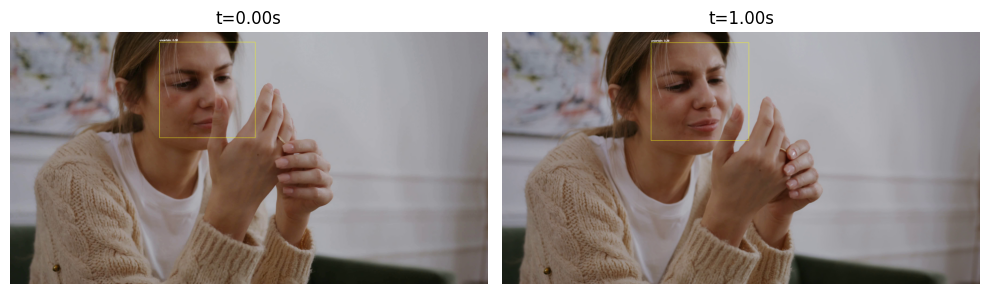

In [6]:
if batch_results:
    first_result = batch_results[0]
    display(Markdown('\n'.join([
        '### Primeiro vídeo processado',
        f"- video_id: `{first_result['video_id']}`",
        f"- annotated video: `{first_result['annotated_video_path']}`",
        f"- json output: `{first_result['json_path']}`",
        f"- limitations: `{'; '.join(first_result['payload']['limitations'])}`",
    ])))
    preview_annotated_frames(first_result, max_frames=MAX_PREVIEW_FRAMES)
else:
    print('Nothing to preview yet. Configure VIDEO_PATHS and run the batch cell first.')
